# Data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Data.csv", sep=';', encoding='latin1')

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['VL'] = pd.to_numeric(df['VL'], errors='coerce')
df['Indice de référence'] = pd.to_numeric(df['Indice de référence'], errors='coerce')

df

,Date,VL,Indice de référence
0,2014-01-02,162.41,118.385031
1,2014-01-03,162.61,118.667605
2,2014-01-06,162.78,118.654332
3,2014-01-07,163.17,119.158908
4,2014-01-08,163.33,119.134825
...,...,...,...
2507,2023-12-21,183.76,146.674949
2508,2023-12-22,184.15,146.818495
2509,2023-12-27,184.32,147.039149
2510,2023-12-28,184.39,146.893033


In [14]:
# Rendements arithmethiques quotidiens 

df['VL_return'] = df['VL'].pct_change()
df['Benchmark_return'] = df['Indice de référence'].pct_change()
df


,Date,VL,Indice de référence,VL_return,Benchmark_return
0,2014-01-02,162.41,118.385031,NaN,NaN
1,2014-01-03,162.61,118.667605,0.001231,0.002387
2,2014-01-06,162.78,118.654332,0.001045,-0.000112
3,2014-01-07,163.17,119.158908,0.002396,0.004252
4,2014-01-08,163.33,119.134825,0.000981,-0.000202
...,...,...,...,...,...
2507,2023-12-21,183.76,146.674949,-0.001250,0.000808
2508,2023-12-22,184.15,146.818495,0.002122,0.000979
2509,2023-12-27,184.32,147.039149,0.000923,0.001503
2510,2023-12-28,184.39,146.893033,0.000380,-0.000994


# Performance sur plusieurs horizons 

In [3]:
# Performance cumulée du fonds et de l’indice sur 1 an, 3 ans, 5 ans et 10 ans

end_date = pd.to_datetime("2023-12-29")

# Fonction pour calculer la performance
def cumulative_performance(df, col, years):
    start_date = end_date - pd.DateOffset(years=years)
    data = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
    start_value = data[col].iloc[0]
    end_value = data[col].iloc[-1]
    return (end_value / start_value) - 1

for years in [1, 3, 5, 10]:
    perf_fund = cumulative_performance(df, 'VL', years)
    perf_benchmark = cumulative_performance(df, 'Indice de référence', years)
    print(f"{years}Y - Fund: {perf_fund:.2%} | Benchmark: {perf_benchmark:.2%}")

1Y - Fund: 7.72% | Benchmark: 3.99%
3Y - Fund: -0.59% | Benchmark: 2.93%
5Y - Fund: 8.64% | Benchmark: 12.19%
10Y - Fund: 13.46% | Benchmark: 23.87%


# Horizon 1 an au 29/12/2023

##  Volatilité annualisée

In [15]:
# Volatilité 1 an au 29/12/2023 sous performances hebdomadaires.

# Période d'un an avant le 29/12/2023
end_date = pd.to_datetime("2023-12-29")
start_date = end_date - pd.DateOffset(years=1)
df_1y = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# Données hebdomadaires, puis les rendements
weekly = df_1y.set_index('Date').resample('W-FRI').last()
weekly['VL_return'] = weekly['VL'].pct_change()
weekly['Benchmark_return'] = weekly['Indice de référence'].pct_change()
print(weekly)

# Volatilité annualisée
vol_fund = weekly['VL_return'].std() * np.sqrt(52)
vol_benchmark = weekly['Benchmark_return'].std() * np.sqrt(52)

print(f"1Y Annualized Volatility - Fund: {vol_fund:.2%} | Benchmark: {vol_benchmark:.2%}")

                VL  Indice de référence  VL_return  Benchmark_return
Date                                                                
2022-12-30  170.92           141.080081        NaN               NaN
2023-01-06  172.47           141.475579   0.009069          0.002803
2023-01-13  174.47           140.627659   0.011596         -0.005993
2023-01-20  174.40           141.357074  -0.000401          0.005187
2023-01-27  175.65           139.981429   0.007167         -0.009732
2023-02-03  177.28           140.245484   0.009280          0.001886
2023-02-10  176.48           138.590202  -0.004513         -0.011803
2023-02-17  175.79           136.759498  -0.003910         -0.013209
2023-02-24  174.98           135.762382  -0.004608         -0.007291
2023-03-03  174.60           135.208587  -0.002172         -0.004079
2023-03-10  174.33           133.948069  -0.001546         -0.009323
2023-03-17  172.38           131.243838  -0.011186         -0.020189
2023-03-24  173.38           131.1

## Bêta entre le fonds et l’indice de référence

In [5]:
weekly_clean = weekly.dropna(subset=['VL_return', 'Benchmark_return'])

# Bêta = Cov(fonds, benchmark) / Var(benchmark)
covariance = np.cov(weekly_clean['VL_return'], weekly_clean['Benchmark_return'])[0, 1]
variance = np.var(weekly_clean['Benchmark_return'])

beta = covariance / variance
print(f"1Y Beta (fund vs benchmark): {beta:.4f}")

1Y Beta (fund vs benchmark): 0.2235


##  Visualization sur les performances annuelles

In [6]:
df_year = df.set_index('Date').copy()

# dernière valeur de chaque année
annual = df_year.resample('Y').last()
annual['VL_start'] = df_year.resample('Y').first()['VL']
annual['Benchmark_start'] = df_year.resample('Y').first()['Indice de référence']
print(annual)

                VL  Indice de référence  VL_return  Benchmark_return  \
Date                                                                   
2014-12-31  167.16           125.222250   0.000658          0.001027   
2015-12-31  165.97           128.959594  -0.001083         -0.001412   
2016-12-31  172.82           131.780523   0.000985          0.001243   
2017-12-31  180.26           134.968063  -0.000831         -0.001902   
2018-12-31  169.61           130.703787   0.001299          0.001187   
2019-12-31  182.52           140.855670   0.000219         -0.000166   
2020-12-31  186.13           142.136290   0.003883         -0.001274   
2021-12-31  189.30           148.777664   0.000159          0.001458   
2022-12-31  170.92           141.080081  -0.000877          0.000474   
2023-12-31  184.27           146.642096  -0.000651         -0.001708   

            VL_start  Benchmark_start  
Date                                   
2014-12-31    162.41       118.385031  
2015-12-31    1

/var/folders/4m/44lhvkwx4nvgyd60ttsx1vk00000gn/T/ipykernel_46758/593031757.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual = df_year.resample('Y').last()
/var/folders/4m/44lhvkwx4nvgyd60ttsx1vk00000gn/T/ipykernel_46758/593031757.py:5: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual['VL_start'] = df_year.resample('Y').first()['VL']
/var/folders/4m/44lhvkwx4nvgyd60ttsx1vk00000gn/T/ipykernel_46758/593031757.py:6: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual['Benchmark_start'] = df_year.resample('Y').first()['Indice de référence']


      VL_return  Benchmark_return
Date                             
2014   0.029247          0.057754
2015  -0.007356          0.029144
2016   0.046189          0.029242
2017   0.041785          0.022296
2018  -0.057984         -0.029878
2019   0.076624          0.077629
2020   0.012456          0.005584
2021   0.015068          0.045563
2022  -0.097190         -0.052799
2023   0.077035          0.036992


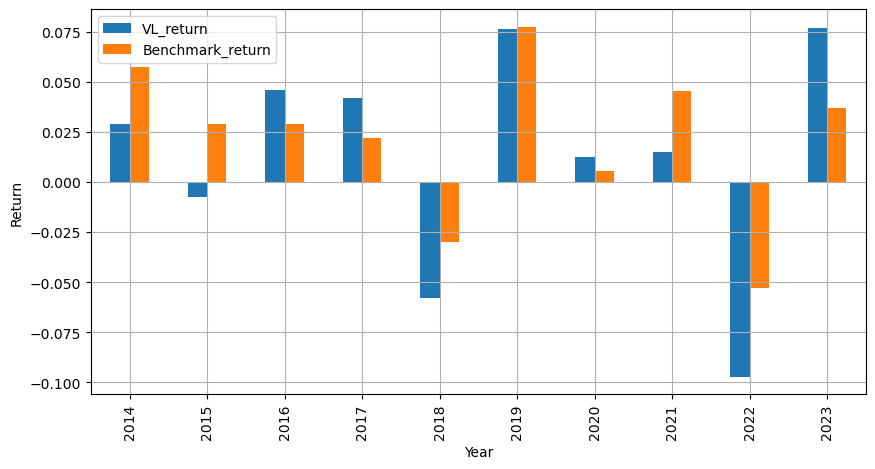

In [7]:
# rendements annuels
annual['VL_return'] = (annual['VL'] / annual['VL_start']) - 1
annual['Benchmark_return'] = (annual['Indice de référence'] / annual['Benchmark_start']) - 1

annual_returns = annual[['VL_return', 'Benchmark_return']]
annual_returns.index = annual_returns.index.year

print(annual_returns)

annual_returns.plot(kind='bar', figsize=(10,5))
plt.ylabel('Return')
plt.xlabel('Year')
plt.grid(True)
plt.show()

## Pire performance du fonds et Maximum drawdown

In [8]:
print(df) 

           Date      VL  Indice de référence  VL_return  Benchmark_return
0    2014-01-02  162.41           118.385031        NaN               NaN
1    2014-01-03  162.61           118.667605   0.001231          0.002387
2    2014-01-06  162.78           118.654332   0.001045         -0.000112
3    2014-01-07  163.17           119.158908   0.002396          0.004252
4    2014-01-08  163.33           119.134825   0.000981         -0.000202
...         ...     ...                  ...        ...               ...
2507 2023-12-21  183.76           146.674949  -0.001250          0.000808
2508 2023-12-22  184.15           146.818495   0.002122          0.000979
2509 2023-12-27  184.32           147.039149   0.000923          0.001503
2510 2023-12-28  184.39           146.893033   0.000380         -0.000994
2511 2023-12-29  184.27           146.642096  -0.000651         -0.001708

[2512 rows x 5 columns]


In [9]:
# Pire performance

# Fenêtre glissante sur 1 mois (~21 jours de bourse)
rolling_1m = df['VL_return'].rolling(window=21).apply(lambda x: (1 + x).prod() - 1) # cumulative return donc (1+r1)...(1+r7)... not cumulative de la valeur VL
print(rolling_1m)

# Trouver la pire performance mensuelle
worst_1m_perf = rolling_1m.min()
print(f"Pire performance: {worst_1m_perf:.2%}")

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
2507    0.028891
2508    0.031653
2509    0.032721
2510    0.030457
2511    0.028465
Name: VL_return, Length: 2512, dtype: float64
Pire performance: -17.92%


In [10]:
# Maximum Drawdown (fonds) 

# maximum cumulé
df['VL_cummax'] = df['VL'].cummax()

# drawdown
df['Drawdown'] = (df['VL'] - df['VL_cummax']) / df['VL_cummax'] # VL not VL_return
print(df)

max_drawdown = df['Drawdown'].min()
print(f"Maximum drawdown: {max_drawdown:.2%}")

           Date      VL  Indice de référence  VL_return  Benchmark_return  \
0    2014-01-02  162.41           118.385031        NaN               NaN   
1    2014-01-03  162.61           118.667605   0.001231          0.002387   
2    2014-01-06  162.78           118.654332   0.001045         -0.000112   
3    2014-01-07  163.17           119.158908   0.002396          0.004252   
4    2014-01-08  163.33           119.134825   0.000981         -0.000202   
...         ...     ...                  ...        ...               ...   
2507 2023-12-21  183.76           146.674949  -0.001250          0.000808   
2508 2023-12-22  184.15           146.818495   0.002122          0.000979   
2509 2023-12-27  184.32           147.039149   0.000923          0.001503   
2510 2023-12-28  184.39           146.893033   0.000380         -0.000994   
2511 2023-12-29  184.27           146.642096  -0.000651         -0.001708   

      VL_cummax  Drawdown  
0        162.41  0.000000  
1        162.61  0.

## VaR paramétrique

In [11]:
# VaR 

end_date = pd.to_datetime("2023-12-29")
start_date = end_date - pd.DateOffset(years=1)
df_1y_daily = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)].copy()

# rendements journaliers
df_1y_daily['VL_return'] = df_1y_daily['VL'].pct_change()
df_1y_daily['Benchmark_return'] = df_1y_daily['Indice de référence'].pct_change()

returns = df_1y_daily[['VL_return', 'Benchmark_return']].dropna()
print(returns)

# VaR 95% (1.645 std): VaR = mu - z.sigma
mu_fund = returns['VL_return'].mean()
sigma_fund = returns['VL_return'].std()
var_fund = mu_fund - 1.645 * sigma_fund

mu_bench = returns['Benchmark_return'].mean()
sigma_bench = returns['Benchmark_return'].std()
var_bench = mu_bench - 1.645 * sigma_bench

print(f"1Y VaR 95% - Fund: {var_fund:.2%} | Benchmark: {var_bench:.2%}")

      VL_return  Benchmark_return
2262  -0.000877          0.000474
2263   0.000995          0.002346
2264   0.002104          0.000359
2265   0.003616          0.000499
2266   0.001104         -0.003413
...         ...               ...
2507  -0.001250          0.000808
2508   0.002122          0.000979
2509   0.000923          0.001503
2510   0.000380         -0.000994
2511  -0.000651         -0.001708

[250 rows x 2 columns]
1Y VaR 95% - Fund: -0.35% | Benchmark: -0.85%


## Backtesting

In [12]:
# Backtesting

# Réutiliser les rendements et la VaR du fonds de la question précédente
var_threshold = var_fund

# les exceptions
returns['VaR_breach'] = returns['VL_return'] < var_threshold
num_breaches = returns['VaR_breach'].sum()
total_days = len(returns)

# Taux de dépassement
breach_rate = num_breaches / total_days

print(f"Dépassement: {num_breaches} out of {total_days} days")
print(f"Taux de dépassement: {breach_rate:.2%} (Expected: 5%)")

Dépassement: 8 out of 250 days
Taux de dépassement: 3.20% (Expected: 5%)
